# H3. Влияние опоздания доставки на оценку заказа

## 1. Постановка задачи

### Бизнес-вопрос

Получают ли заказы, доставленные позже обещанного срока, более низкие оценки покупателей?

### Нулевая гипотеза H0

Заказы с опозданием **не склонны получать более низкие оценки**, чем заказы, доставленные вовремя.

### Альтернативная гипотеза H1

Заказы с опозданием **склонны получать более низкие оценки**, чем заказы, доставленные вовремя.

### Метод

Для проверки гипотезы используется односторонний критерий Манна–Уитни, поскольку:

- сравниваются две независимые группы: `Late` и `On time`;
- `review_score` является порядковым признаком со значениями от 1 до 5;
- тест не требует нормального распределения;
- проверяется направленная гипотеза: оценки опоздавших заказов ниже.

Дополнительно рассчитывается **rank-biserial correlation** для оценки размера эффекта.

Уровень значимости:
alpha = 0.05

### Определение опоздания

Заказ считается опоздавшим, если **календарная дата фактической доставки позже календарной даты ожидаемой доставки**.

Сравнение выполняется по датам, а не по полным timestamp, поскольку `order_estimated_delivery_date` в Olist фактически задаёт обещанный день доставки.


## 2. Подготовка окружения

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import stats

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [2]:
import os
from dotenv import load_dotenv

In [3]:
_ = load_dotenv()

In [4]:
DB_USERNAME = os.getenv("DB_USERNAME")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USERNAME,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
)

In [5]:
engine = create_engine(url=url)

## 3. Получение данных

Для анализа используются только доставленные заказы, для которых известны:

- фактическая дата доставки;
- ожидаемая дата доставки;
- оценка покупателя.

Если для одного `order_id` существует несколько отзывов, используется **самый новый отзыв по `review_creation_date`**.

Для каждого заказа рассчитывается отклонение от обещанной даты:


delay_days =
actual_delivery_date - estimated_delivery_date

где:

- `delay_days > 0` — заказ доставлен с опозданием;
- `delay_days <= 0` — заказ доставлен вовремя или раньше срока.


In [6]:
query = """
WITH latest_reviews AS (
    SELECT
        review_id,
        order_id,
        review_score,
        review_creation_date,
        ROW_NUMBER() OVER (
            PARTITION BY order_id
            ORDER BY
                review_creation_date DESC NULLS LAST
        ) AS rn
    FROM order_reviews
    WHERE review_score IS NOT NULL
)

SELECT
    o.order_id,
    r.review_id,
    r.review_score,
    (
        o.order_delivered_customer_date::date
        - o.order_estimated_delivery_date::date
    ) AS delay_days,
    (
        o.order_delivered_customer_date::date
        > o.order_estimated_delivery_date::date
    ) AS is_late
FROM orders AS o
JOIN latest_reviews AS r
    ON o.order_id = r.order_id
    AND r.rn = 1
WHERE
    o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
    AND o.order_estimated_delivery_date IS NOT NULL;
"""

df = pd.read_sql(sql=query, con=engine)

## 4. Проверка качества данных

Перед статистическим анализом проверим:

- размер выборки;
- уникальность `order_id`;
- отсутствие пропущенных значений;
- допустимый диапазон оценок от 1 до 5;
- согласованность признаков `delay_days` и `is_late`;
- количество заказов в каждой группе.


In [7]:
df.head()

,order_id,review_id,review_score,delay_days,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,97ca439bc427b48bc1cd7177abe71365,5,-9,False
1,00018f77f2f0320c557190d7a144bdd3,7b07bacd811c4117b742569b04ce3580,4,-3,False
2,000229ec398224ef6ca0657da4fc703e,0c5b33dea94867d1ac402749e5438e8b,5,-14,False
3,00024acbcdf0a6daa1e931b038114c75,f4028d019cb58564807486a6aaf33817,4,-6,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,940144190dcba6351888cafa43f3a3a5,5,-16,False


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95824 entries, 0 to 95823
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   order_id      95824 non-null  str  
 1   review_id     95824 non-null  str  
 2   review_score  95824 non-null  int64
 3   delay_days    95824 non-null  int64
 4   is_late       95824 non-null  bool 
dtypes: bool(1), int64(2), str(2)
memory usage: 3.0 MB


In [9]:
quality_checks = pd.Series({
    "rows": len(df),
    "unique_orders": df["order_id"].nunique(),
    "duplicate_orders": df["order_id"].duplicated().sum(),
    "missing_values": df.isna().sum().sum(),
    "invalid_review_scores": (~df["review_score"].between(1, 5)).sum(),
    "late_flag_mismatch": (
        (df["delay_days"] > 0) != df["is_late"]
    ).sum(),
    "late_orders": df["is_late"].sum(),
    "on_time_orders": (~df["is_late"]).sum(),
})

quality_checks

rows                     95824
unique_orders            95824
duplicate_orders             0
missing_values               0
invalid_review_scores        0
late_flag_mismatch           0
late_orders               6381
on_time_orders           89443
dtype: int64

In [10]:
df["delivery_status"] = np.where(
    df["is_late"],
    "Late",
    "On time",
)

df["delivery_status"] = pd.Categorical(
    df["delivery_status"],
    categories=["On time", "Late"],
    ordered=True,
)

## 5. Описательный анализ

Сравним размер групп и распределение оценок для заказов, доставленных вовремя и с опозданием.


In [24]:
delivery_status_distribution = (
    df["delivery_status"]
    .value_counts(sort=False)
)

delivery_status_share = (
    df["delivery_status"]
    .value_counts(normalize=True, sort=False)
    .mul(100)
    .round(2)
)

pd.DataFrame({
    "orders": delivery_status_distribution,
    "share_pct": delivery_status_share,
})

,orders,share_pct
delivery_status,,
On time,89443,93.34
Late,6381,6.66


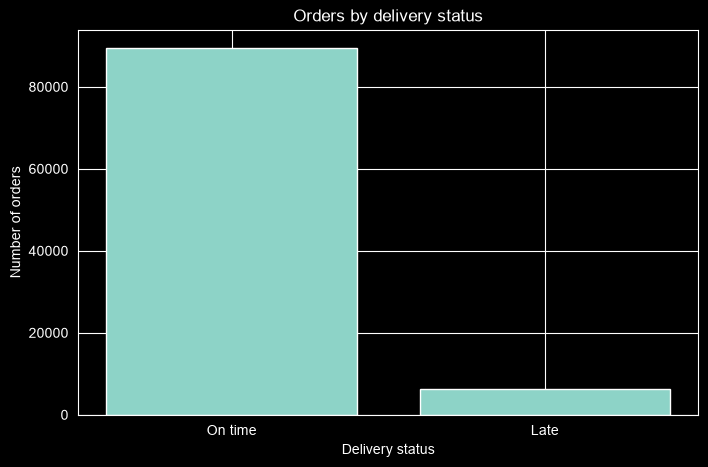

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    delivery_status_distribution.index.astype(str),
    delivery_status_distribution.values,
)

plt.title("Orders by delivery status")
plt.xlabel("Delivery status")
plt.ylabel("Number of orders")

plt.show()

### 5.1. Распределение оценок

Сравним доли оценок от 1 до 5 внутри каждой группы. Нормирование по строкам позволяет корректно сравнивать группы даже при разном количестве заказов.


In [29]:
review_distribution = pd.crosstab(
    df["delivery_status"],
    df["review_score"],
    normalize="index",
).mul(100)

review_distribution.round(2)

review_score,1,2,3,4,5
delivery_status,,,,,
On time,6.62,2.65,8.08,20.40,62.26
Late,53.78,8.62,10.88,10.17,16.55


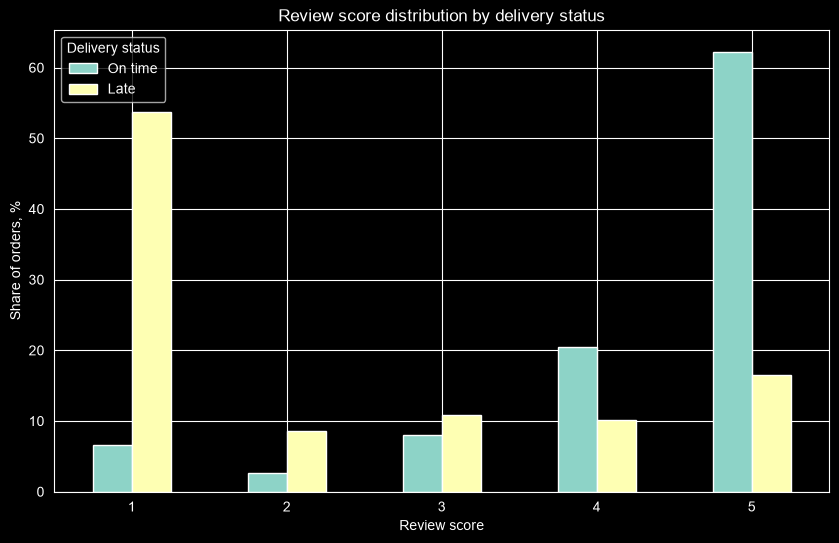

In [14]:
ax = review_distribution.T.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_title("Review score distribution by delivery status")
ax.set_xlabel("Review score")
ax.set_ylabel("Share of orders, %")
ax.legend(title="Delivery status")
ax.tick_params(axis="x", rotation=0)

plt.show()

### 5.2. Описательная статистика по группам

Рассчитаем число наблюдений, среднее, медиану, стандартное отклонение и квартили оценки заказа для каждой группы.


In [30]:
review_stats = (
    df.groupby("delivery_status")["review_score"].agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    .round(2)
)

review_stats

,count,mean,median,std,q25,q75
delivery_status,,,,,,
On time,89443,4.29,5.0,1.15,4.0,5.0
Late,6381,2.27,1.0,1.57,1.0,4.0


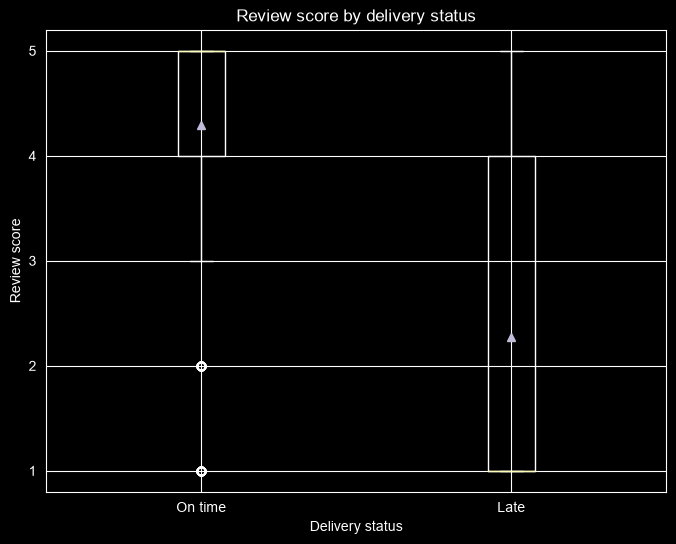

In [16]:
on_time_scores = df.loc[
    ~df["is_late"],
    "review_score",
].to_numpy()

late_scores = df.loc[
    df["is_late"],
    "review_score",
].to_numpy()

plt.figure(figsize=(8, 6))

plt.boxplot(
    [on_time_scores, late_scores],
    tick_labels=["On time", "Late"],
    showmeans=True,
)

plt.title("Review score by delivery status")
plt.xlabel("Delivery status")
plt.ylabel("Review score")
plt.yticks(range(1, 6))

plt.show()

## 6. Проверка статистической гипотезы

Для сравнения распределений `review_score` между двумя независимыми группами используется критерий Манна–Уитни.

Направление альтернативы:

Late < On time

Критерий принятия решения:

- если (p < 0.05), нулевая гипотеза отвергается;
- если (p >= 0.05), оснований для отклонения нулевой гипотезы недостаточно.

Из-за большого количества наблюдений и наличия повторяющихся значений оценок используется асимптотический вариант теста.


In [17]:
ALPHA = 0.05

mann_whitney_result = stats.mannwhitneyu(
    late_scores,
    on_time_scores,
    alternative="less",
    method="asymptotic",
)

u_statistic = mann_whitney_result.statistic
p_value = mann_whitney_result.pvalue

print(f"Mann-Whitney U: {u_statistic:,.0f}")

if p_value < 0.001:
    print("p-value: < 0.001")
else:
    print(f"p-value: {p_value:.4f}")

if p_value < ALPHA:
    print("Reject H0")
    print("Late orders tend to receive lower review scores.")
else:
    print("Fail to reject H0")
    print(
        "There is insufficient evidence that "
        "late orders receive lower review scores."
    )

Mann-Whitney U: 103,366,202
p-value: < 0.001
Reject H0
Late orders tend to receive lower review scores.


## 7. Размер эффекта

При большой выборке одного `p-value` недостаточно: даже небольшие различия могут быть статистически значимыми.

Поэтому дополнительно рассчитаем **rank-biserial correlation**:

rbc =
2 * mannwhitneyu / (n_late * n_on_time) - 1

В данной постановке:

- rbc < 0 — опоздавшие заказы склонны получать более низкие оценки;
- rbc ≈ 0 — практическое различие невелико;
- чем ближе |rbc| к 1, тем сильнее различие между группами.


In [18]:
n_late = len(late_scores)
n_on_time = len(on_time_scores)

rank_biserial = (
    2 * u_statistic / (n_late * n_on_time)
    - 1
)

print(f"Rank-biserial correlation: {rank_biserial:.4f}")

Rank-biserial correlation: -0.6378


### 7.1. Вероятностная интерпретация эффекта

Дополнительно выразим результат как вероятность превосходства.

`common_language_effect` показывает вероятность того, что случайно выбранный опоздавший заказ получит более высокую оценку, чем случайно выбранный заказ, доставленный вовремя, с половинным весом для равных оценок.


In [19]:
common_language_effect = (
    u_statistic / (n_late * n_on_time)
)

print(
    "P(late score > on-time score) "
    f"with 0.5 weight for ties: "
    f"{common_language_effect:.4f}"
)

P(late score > on-time score) with 0.5 weight for ties: 0.1811


## 8. Итоговая таблица

In [20]:
results = pd.DataFrame({
    "metric": [
        "Mann-Whitney U",
        "p-value",
        "rank-biserial correlation",
        "common language effect",
        "late orders",
        "on-time orders",
        "alpha",
    ],
    "value": [
        u_statistic,
        p_value,
        rank_biserial,
        common_language_effect,
        n_late,
        n_on_time,
        ALPHA,
    ],
})

results

,metric,value
0,Mann-Whitney U,1.033662e+08
1,p-value,0.000000e+00
2,rank-biserial correlation,-6.377791e-01
3,common language effect,1.811104e-01
4,late orders,6.381000e+03
5,on-time orders,8.944300e+04
6,alpha,5.000000e-02


## 9. Результаты и вывод

Итог необходимо интерпретировать одновременно по трём уровням:

1. **Статистическая значимость** — позволяет решить, есть ли основания отвергнуть H0.
2. **Направление различий** — показывает, действительно ли оценки опоздавших заказов ниже.
3. **Размер эффекта** — показывает, насколько велико различие с практической точки зрения.

Ниже формируется итоговый вывод на основе рассчитанных значений.


In [21]:
late_mean = df.loc[
    df["is_late"],
    "review_score",
].mean()

on_time_mean = df.loc[
    ~df["is_late"],
    "review_score",
].mean()

late_median = df.loc[
    df["is_late"],
    "review_score",
].median()

on_time_median = df.loc[
    ~df["is_late"],
    "review_score",
].median()

print("Statistical conclusion")
print("-" * 60)

if p_value < ALPHA:
    print(
        "H0 is rejected: late orders tend to receive "
        "lower review scores than on-time orders."
    )
else:
    print(
        "H0 is not rejected: there is insufficient evidence "
        "that late orders receive lower review scores."
    )

print()
print("Descriptive results")
print(f"Late orders mean score:     {late_mean:.2f}")
print(f"On-time orders mean score:  {on_time_mean:.2f}")
print(f"Late orders median score:   {late_median:.2f}")
print(f"On-time median score:       {on_time_median:.2f}")
print(f"Rank-biserial correlation:  {rank_biserial:.4f}")

print()
print("Business interpretation")

if p_value < ALPHA and rank_biserial < 0:
    print(
        "Delivery delay is associated with lower customer ratings. "
        "The practical importance of this relationship should be "
        "judged by the magnitude of the rank-biserial correlation, "
        "not by p-value alone."
    )
else:
    print(
        "The analysis does not provide clear evidence that "
        "late delivery is associated with lower customer ratings."
    )

print()
print(
    "This analysis identifies an association and does not by itself "
    "establish a causal effect of delivery delay on review score."
)

Statistical conclusion
------------------------------------------------------------
H0 is rejected: late orders tend to receive lower review scores than on-time orders.

Descriptive results
Late orders mean score:     2.27
On-time orders mean score:  4.29
Late orders median score:   1.00
On-time median score:       5.00
Rank-biserial correlation:  -0.6378

Business interpretation
Delivery delay is associated with lower customer ratings. The practical importance of this relationship should be judged by the magnitude of the rank-biserial correlation, not by p-value alone.

This analysis identifies an association and does not by itself establish a causal effect of delivery delay on review score.
